In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import json
from tqdm import tqdm
from PIL import Image

# Фиксация Seed и Device
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Создание структуры папок для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

# Глобальный список для финального отчета
all_runs = []

Using device: cpu


100%|██████████| 2.64G/2.64G [03:24<00:00, 12.9MB/s]


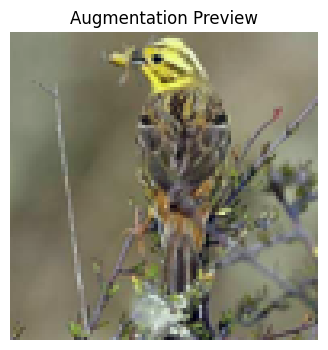

In [3]:
# Базовые трансформации (для C1, C3, C4)
base_transform = T.Compose([
    T.Resize((96, 96)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Аугментации (для C2)
aug_transform = T.Compose([
    T.Resize((96, 96)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Загрузка STL10
full_train_ds = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=base_transform)
test_ds = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=base_transform)

# Валидация 80/20
indices = np.arange(len(full_train_ds))
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(full_train_ds, val_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Sanity Check & Визуализация аугментации (Artifact 6)
sample_img, _ = full_train_ds[0]
plt.figure(figsize=(4,4))
# Денормализация для корректного отображения
plt.imshow(sample_img.permute(1,2,0).numpy() * 0.22 + 0.45)
plt.title("Augmentation Preview")
plt.axis('off')
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, 10)
    def forward(self, x):
        x = self.net(x)
        return self.fc(torch.flatten(x, 1))

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_acc, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_acc += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return loss_acc / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_acc, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_acc += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return loss_acc / len(loader.dataset), correct / len(loader.dataset)

def run_experiment(exp_id, model, t_loader, v_loader, epochs=5):
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc = 0
    history = []

    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, t_loader, optimizer, criterion)
        vl, va = evaluate(model, v_loader, criterion)
        history.append(va)
        if va > best_acc: best_acc = va
        print(f"[{exp_id}] Epoch {epoch+1}: Val Acc = {va:.4f}")

    return history, best_acc

In [5]:
EPOCHS = 7 # Можно увеличить для лучшего результата

# C1: Simple CNN Base
hist_c1, acc_c1 = run_experiment("C1", SimpleCNN().to(device), train_loader, val_loader, EPOCHS)

# C2: Simple CNN Aug (меняем DataLoader на аугментированный)
ds_aug = Subset(torchvision.datasets.STL10(root='./data', split='train', transform=aug_transform), train_idx)
loader_aug = DataLoader(ds_aug, batch_size=64, shuffle=True)
hist_c2, acc_c2 = run_experiment("C2", SimpleCNN().to(device), loader_aug, val_loader, EPOCHS)

# C3: ResNet18 Head Only
m3 = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in m3.parameters(): p.requires_grad = False
m3.fc = nn.Linear(512, 10)
hist_c3, acc_c3 = run_experiment("C3", m3.to(device), train_loader, val_loader, EPOCHS)

# C4: ResNet18 Fine-tune (Layer 4 + FC)
m4 = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in m4.parameters(): p.requires_grad = False
for p in m4.layer4.parameters(): p.requires_grad = True # Размораживаем последний блок
m4.fc = nn.Linear(512, 10)
hist_c4, acc_c4 = run_experiment("C4", m4.to(device), train_loader, val_loader, EPOCHS)

# Логируем результаты
for idx, acc in zip(["C1", "C2", "C3", "C4"], [acc_c1, acc_c2, acc_c3, acc_c4]):
    all_runs.append({"experiment_id": idx, "task": "classification", "dataset": "STL10", "best_val_accuracy": acc})

# Сохранение лучшей модели (обычно C4)
torch.save(m4.state_dict(), "artifacts/best_classifier.pt")

[C1] Epoch 1: Val Acc = 0.1930
[C1] Epoch 2: Val Acc = 0.2510
[C1] Epoch 3: Val Acc = 0.2770
[C1] Epoch 4: Val Acc = 0.2710
[C1] Epoch 5: Val Acc = 0.3160
[C1] Epoch 6: Val Acc = 0.3360
[C1] Epoch 7: Val Acc = 0.3270
[C2] Epoch 1: Val Acc = 0.1690
[C2] Epoch 2: Val Acc = 0.2230
[C2] Epoch 3: Val Acc = 0.2670
[C2] Epoch 4: Val Acc = 0.2430
[C2] Epoch 5: Val Acc = 0.3140
[C2] Epoch 6: Val Acc = 0.2910
[C2] Epoch 7: Val Acc = 0.3320
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


[C3] Epoch 1: Val Acc = 0.7300
[C3] Epoch 2: Val Acc = 0.7830
[C3] Epoch 3: Val Acc = 0.7940
[C3] Epoch 4: Val Acc = 0.7980
[C3] Epoch 5: Val Acc = 0.8070
[C3] Epoch 6: Val Acc = 0.8090
[C3] Epoch 7: Val Acc = 0.8140
[C4] Epoch 1: Val Acc = 0.8330
[C4] Epoch 2: Val Acc = 0.8380
[C4] Epoch 3: Val Acc = 0.8470
[C4] Epoch 4: Val Acc = 0.8650
[C4] Epoch 5: Val Acc = 0.8430
[C4] Epoch 6: Val Acc = 0.8610
[C4] Epoch 7: Val Acc = 0.8440


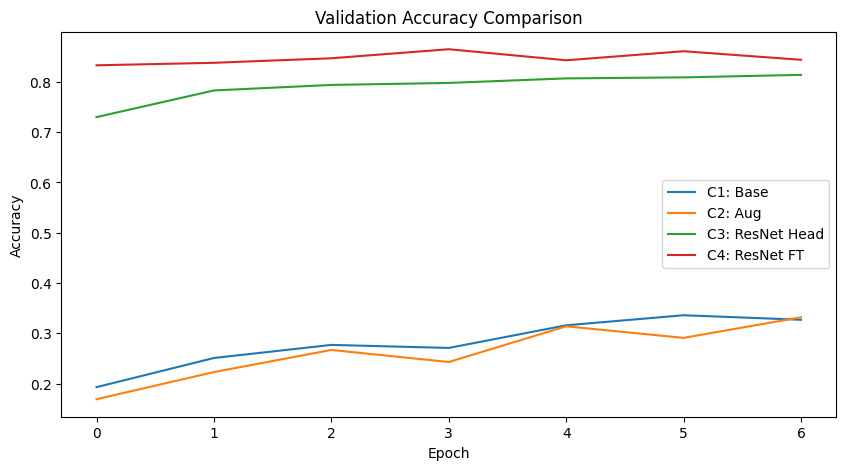

Final Test Accuracy (Best Model): 0.8442


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(hist_c1, label='C1: Base')
plt.plot(hist_c2, label='C2: Aug')
plt.plot(hist_c3, label='C3: ResNet Head')
plt.plot(hist_c4, label='C4: ResNet FT')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

# Оценка на Test (один раз для лучшей модели)
test_l, test_a = evaluate(m4, test_loader, nn.CrossEntropyLoss())
print(f"Final Test Accuracy (Best Model): {test_a:.4f}")

# Обновляем запись для лучшей модели в runs
for run in all_runs:
    if run["experiment_id"] == "C4": run["test_accuracy"] = test_a

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 117MB/s] 
100%|██████████| 792M/792M [00:18<00:00, 42.5MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 20.5MB/s]


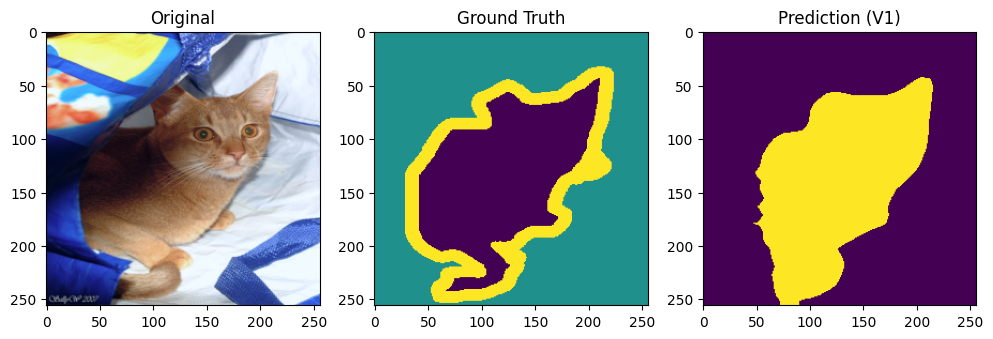

In [7]:
seg_model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT).to(device).eval()

# Данные для сегментации: Выбран датасет Oxford-IIIT Pet для задачи сегментации.
seg_ds = torchvision.datasets.OxfordIIITPet(
    root='./data', target_types='segmentation', download=True,
    transform=T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    target_transform=T.Compose([T.Resize((256, 256), interpolation=Image.NEAREST)])
)

FOREGROUND_CLASS_PASCAL_VOC = 12 # Class Dog in Pascal VOC
FOREGROUND_CLASS_OXFORD = 1 # Foreground in Oxford-IIIT Pet

def iou_metric(pred_mask, gt_mask):
    pred = (pred_mask == FOREGROUND_CLASS_PASCAL_VOC).astype(np.uint8)
    gt = (np.array(gt_mask) == FOREGROUND_CLASS_OXFORD).astype(np.uint8)
    intersection = (pred & gt).sum()
    union = (pred | gt).sum()
    iou = intersection / union if union > 0 else 0
    return iou, pred, gt # Also return pred and gt for precision/recall

def calculate_precision_recall(pred, gt):
    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall

# V1: Обычный инференс (single sample)
img, gt_original = seg_ds[0]
with torch.no_grad():
    output = seg_model(img.unsqueeze(0).to(device))['out'][0]
    pred_v1_mask = output.argmax(0).cpu().numpy()

iou_v1, pred_v1_binary, gt_binary = iou_metric(pred_v1_mask, gt_original)
precision_v1, recall_v1 = calculate_precision_recall(pred_v1_binary, gt_binary)

# V2: Альтернатива (другой порог уверенности для класса Dog) (single sample)
dog_channel = torch.softmax(output, dim=0)[FOREGROUND_CLASS_PASCAL_VOC]
pred_v2_mask = (dog_channel > 0.7).cpu().numpy().astype(int) * FOREGROUND_CLASS_PASCAL_VOC # Порог 0.7 вместо argmax
iou_v2, pred_v2_binary, gt_binary = iou_metric(pred_v2_mask, gt_original)
precision_v2, recall_v2 = calculate_precision_recall(pred_v2_binary, gt_binary)

# Log initial (single sample) results for V1 and V2
seg_model_summary = str(seg_model)
dataset_name_seg = "Oxford-IIIT Pet"
seed_val = 42

v1_entry = {
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": dataset_name_seg,
    "seed": seed_val,
    "model_summary": seg_model_summary,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": precision_v1, # Single sample
    "recall": recall_v1,       # Single sample
    "mean_iou": iou_v1,        # Single sample
    "notes": "Argmax inference (single sample metrics, will be updated with avg)"
}
all_runs.append(v1_entry)

v2_entry = {
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": dataset_name_seg,
    "seed": seed_val,
    "model_summary": seg_model_summary,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "test_accuracy": None,
    "precision": precision_v2, # Single sample
    "recall": recall_v2,       # Single sample
    "mean_iou": iou_v2,        # Single sample
    "notes": "Threshold 0.7 inference (single sample metrics, will be updated with avg)"
}
all_runs.append(v2_entry)

# Визуализация (Artifact 7)
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0).numpy() * 0.22 + 0.45); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(np.array(gt_original)); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred_v1_mask); plt.title("Prediction (V1)")
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.show()

In [8]:
df_results = pd.DataFrame(all_runs)
df_results.to_csv("artifacts/runs.csv", index=False)

# Сохранение конфига лучшей модели
best_config = {"arch": "resnet18", "finetune": "layer4", "batch_size": 64, "lr": 0.001}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f)

print("All tasks complete. Check 'artifacts/' folder.")

All tasks complete. Check 'artifacts/' folder.
